In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#read data
df = pd.read_csv("/home/msft.us.txt")

In [ ]:
#drop duplication values
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates()

In [ ]:
#get values in the correct range
df = df[(df["Date"] >= "2009-01-01") & (df["Date"] <= "2017-12-31")].copy()


In [ ]:
#integrity checks
print("Nulls:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Nulls:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
Duplicates: 0
Date range: 2009-01-02 00:00:00 to 2017-11-10 00:00:00


In [ ]:
#Feature engineering
df["DailyReturn"] = df["Close"].pct_change()
df["NormalizedClose"] = df["Close"] / df["Close"].iloc[0] * 100
df["Volatility20"] = df["DailyReturn"].rolling(20).std()
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()


In [ ]:
#Summary stats
summary = {
    "avg_daily_return": df["DailyReturn"].mean(),
    "volatility_daily": df["DailyReturn"].std(),
    "avg_volume": df["Volume"].mean(),
    "min_daily_return": df["DailyReturn"].min(),
    "max_daily_return": df["DailyReturn"].max(),
}
print(summary)

{'avg_daily_return': np.float64(0.0008328001889917616), 'volatility_daily': 0.015393718460043131, 'avg_volume': np.float64(51105168.37724014), 'min_daily_return': -0.11705335712966947, 'max_daily_return': 0.10511721704058496}


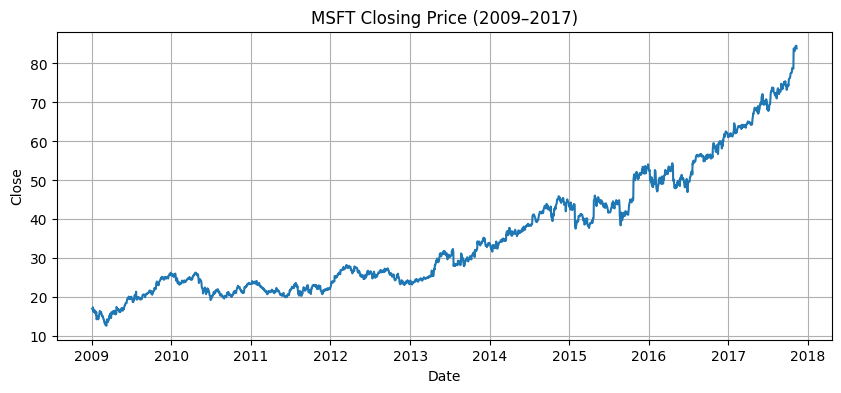

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Close"])
plt.title("MSFT Closing Price (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

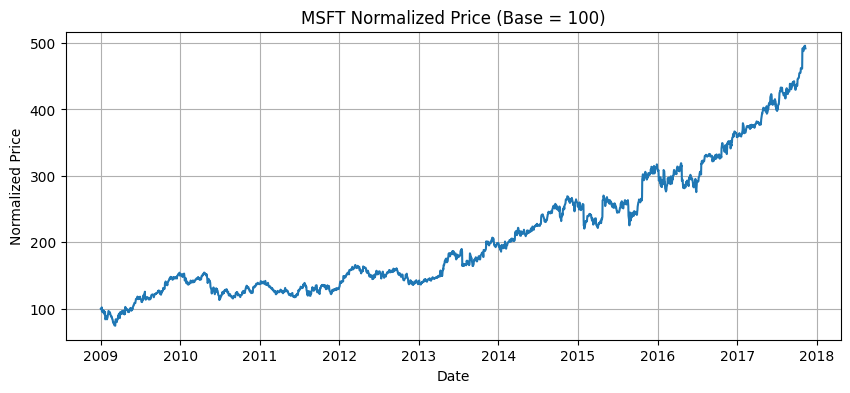

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["NormalizedClose"])
plt.title("MSFT Normalized Price (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.grid(True)
plt.show()

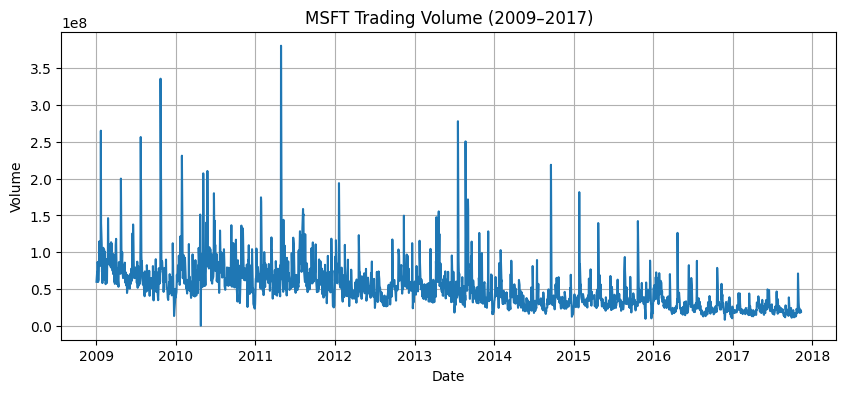

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("MSFT Trading Volume (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


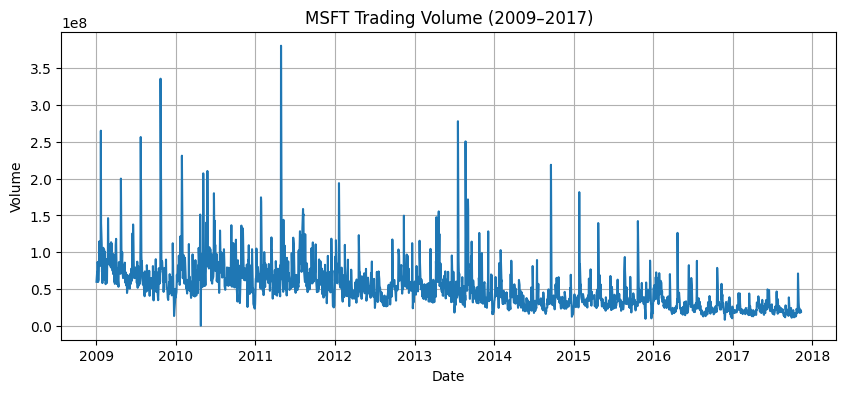

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Volume"])
plt.title("MSFT Trading Volume (2009–2017)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()


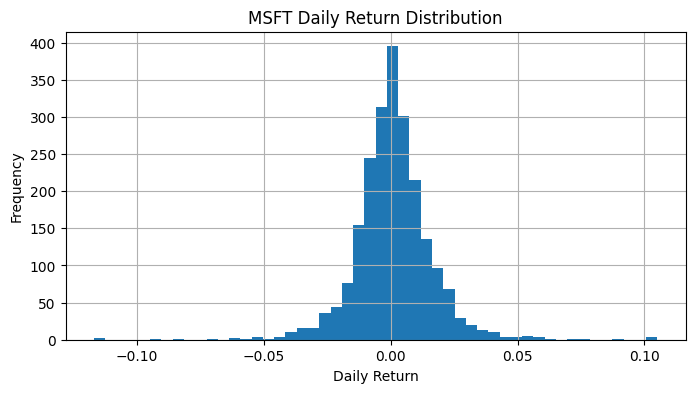

In [ ]:

plt.figure(figsize=(8,4))
plt.hist(df["DailyReturn"].dropna(), bins=50)
plt.title("MSFT Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()